# Lab 3: Gesture Recognition using Convolutional Neural Networks

In this lab you will train a convolutional neural network to make classifications on different hand gestures. By the end of the lab, you should be able to:

1. Load and split data for training, validation and testing
2. Train a Convolutional Neural Network
3. Apply transfer learning to improve your model

Note that for this lab we will not be providing you with any starter code. You should be able to take the code used in previous labs, tutorials and lectures and modify it accordingly to complete the tasks outlined below.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to **File > Print** and then save as PDF. The Colab instructions
has more information. Make sure to review the PDF submission to ensure that your answers are easy to read. Make sure that your text is not cut off at the margins. 

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

## Colab Link

Include a link to your colab file here

Colab Link: https://colab.research.google.com/github/Ibrahim925/aps360-labs/blob/master/Lab%203/Lab_3_Gesture_Recognition.ipynb

## Dataset

American Sign Language (ASL) is a complete, complex language that employs signs made by moving the
hands combined with facial expressions and postures of the body. It is the primary language of many
North Americans who are deaf and is one of several communication options used by people who are deaf or
hard-of-hearing. The hand gestures representing English alphabet are shown below. This lab focuses on classifying a subset
of these hand gesture images using convolutional neural networks. Specifically, given an image of a hand
showing one of the letters A-I, we want to detect which letter is being represented.

![alt text](https://www.disabled-world.com/pics/1/asl-alphabet.jpg)

## Part B. Building a CNN [50 pt]

For this lab, we are not going to give you any starter code. You will be writing a convolutional neural network
from scratch. You are welcome to use any code from previous labs, lectures and tutorials. You should also
write your own code.

You may use the PyTorch documentation freely. You might also find online tutorials helpful. However, all
code that you submit must be your own.

Make sure that your code is vectorized, and does not contain obvious inefficiencies (for example, unecessary
for loops, or unnecessary calls to unsqueeze()). Ensure enough comments are included in the code so that
your TA can understand what you are doing. It is your responsibility to show that you understand what you
write.

**This is much more challenging and time-consuming than the previous labs.** Make sure that you
give yourself plenty of time by starting early.

### 1. Data Loading and Splitting [5 pt]

Download the anonymized data provided on Quercus. To allow you to get a heads start on this project we will provide you with sample data from previous years. Split the data into training, validation, and test sets.

Note: Data splitting is not as trivial in this lab. We want our test set to closely resemble the setting in which
our model will be used. In particular, our test set should contain hands that are never seen in training!

Explain how you split the data, either by describing what you did, or by showing the code that you used.
Justify your choice of splitting strategy. How many training, validation, and test images do you have?

For loading the data, you can use plt.imread as in Lab 1, or any other method that you choose. You may find
torchvision.datasets.ImageFolder helpful. (see https://pytorch.org/docs/stable/torchvision/datasets.html?highlight=image%20folder#torchvision.datasets.ImageFolder
) 

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [3]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
dataset_path = "Lab3_Gestures_Summer/"
dataset = datasets.ImageFolder(root=dataset_path, transform=data_transforms)

data_loader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [4]:
dataset.classes

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']

In [5]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

### 2. Model Building and Sanity Checking [15 pt]

### Part (a) Convolutional Network - 5 pt

Build a convolutional neural network model that takes the (224x224 RGB) image as input, and predicts the gesture
letter. Your model should be a subclass of nn.Module. Explain your choice of neural network architecture: how
many layers did you choose? What types of layers did you use? Were they fully-connected or convolutional?
What about other decisions like pooling layers, activation functions, number of channels / hidden units?

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    """
    Architecture:
    - 3 convolutional blocks, each with Conv2d -> BatchNorm -> ReLU -> MaxPool
    - Progressively increasing channels: 32 -> 64 -> 128
    - 2 fully connected layers for classification

    Design choices:
    - Conv2d layers (3x3 kernels): extract spatial features from images
    - BatchNorm: stabilizes training and allows higher learning rates
    - ReLU activation: introduces non-linearity
    - MaxPool (2x2): reduces spatial dimensions, provides translation invariance
    - Dropout: prevents overfitting
    """

    def __init__(self, num_classes=9):
        super(CustomCNN, self).__init__()

        # Convolutional Block 1: 3 channels -> 32 channels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 2: 32 channels -> 64 channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 3: 64 channels -> 128 channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # After 3 pooling layers: 224x224 -> 112x112 -> 56x56 -> 28x28
        # Feature map size: 28x28x128 = 100352

        # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Convolutional Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Convolutional Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)

        # Convolutional Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)

        # Flatten for fully connected layers
        x = x.view(x.size(0), -1)

        # Fully Connected Layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### Part (b) Training Code - 5 pt

Write code that trains your neural network given some training data. Your training code should make it easy
to tweak the usual hyperparameters, like batch size, learning rate, and the model object itself. Make sure
that you are checkpointing your models from time to time (the frequency is up to you). Explain your choice
of loss function and optimizer.

In [11]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def train_model(model,
                train_loader,
                val_loader,
                optimizer,
                criterion,
                num_epochs=10,
                scheduler=None,
                checkpoint_interval=2,
                checkpoint_prefix="cnn_checkpoint"):
    model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += inputs.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss / total
        train_acc = running_corrects / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{num_epochs} - "
              f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
              f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

        if epoch % checkpoint_interval == 0 or epoch == num_epochs:
            checkpoint_path = f"{checkpoint_prefix}_epoch_{epoch}.pth"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc
            }, checkpoint_path)

    return history

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example hyperparameters and setup
num_classes = len(dataset.classes)
model = CustomCNN(num_classes=num_classes)

criterion = nn.CrossEntropyLoss() # Best for classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Standard optimizer choice

# Step learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=7,
    scheduler=scheduler,
    checkpoint_interval=3,
    checkpoint_prefix="customcnn"
)

Epoch 1/7 - train_loss: 7.0297, train_acc: 0.1146, val_loss: 2.1943, val_acc: 0.1235
Epoch 2/7 - train_loss: 2.1982, train_acc: 0.1095, val_loss: 2.1945, val_acc: 0.1265
Epoch 3/7 - train_loss: 2.1976, train_acc: 0.1114, val_loss: 2.1954, val_acc: 0.1235
Epoch 4/7 - train_loss: 2.1973, train_acc: 0.1127, val_loss: 2.1963, val_acc: 0.1235
Epoch 5/7 - train_loss: 2.1971, train_acc: 0.1133, val_loss: 2.1960, val_acc: 0.1235
Epoch 6/7 - train_loss: 2.1963, train_acc: 0.1133, val_loss: 2.1963, val_acc: 0.1265
Epoch 7/7 - train_loss: 2.1967, train_acc: 0.1140, val_loss: 2.1971, val_acc: 0.1295


### Part (c) “Overfit” to a Small Dataset - 5 pt

One way to sanity check our neural network model and training code is to check whether the model is capable
of “overfitting” or “memorizing” a small dataset. A properly constructed CNN with correct training code
should be able to memorize the answers to a small number of images quickly.

Construct a small dataset (e.g. just the images that you have collected). Then show that your model and
training code is capable of memorizing the labels of this small data set.

With a large batch size (e.g. the entire small dataset) and learning rate that is not too high, You should be
able to obtain a 100% training accuracy on that small dataset relatively quickly (within 200 iterations).

Reached 100 % training accuracy at iteration 38


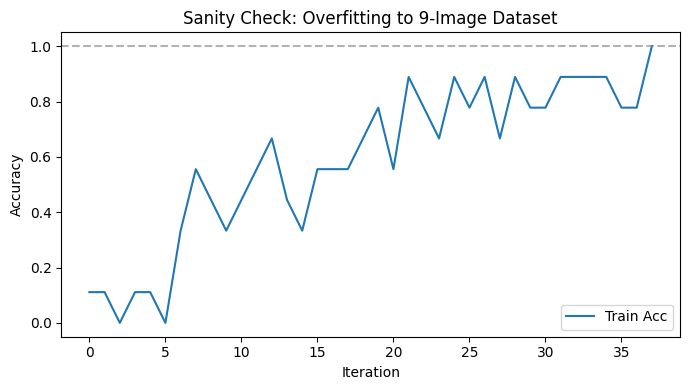

Final training accuracy: 1.0000


In [8]:
# We take only the first 9 images (one per class) from our training set and
# verify that the model can drive training accuracy to 100 % quickly.

import matplotlib.pyplot as plt
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Grab one sample per class (9 total) from the full dataset
small_indices = []
class_seen = set()
for idx in range(len(dataset)):
    _, label = dataset[idx]
    if label not in class_seen:
        small_indices.append(idx)
        class_seen.add(label)
    if len(class_seen) == len(dataset.classes):
        break

small_dataset = Subset(dataset, small_indices)
# Use the entire small dataset as one batch so gradient signal is clean
small_loader = DataLoader(small_dataset, batch_size=len(small_indices), shuffle=False)

# Fresh model + aggressive learning rate to encourage memorisation
small_model = CustomCNN(num_classes=len(dataset.classes)).to(device)
small_optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-2)
small_criterion = nn.CrossEntropyLoss()

overfit_train_acc = []
NUM_ITERS = 150

for iteration in range(1, NUM_ITERS + 1):
    small_model.train()
    for inputs, labels in small_loader:          # one batch = whole small set
        inputs, labels = inputs.to(device), labels.to(device)
        small_optimizer.zero_grad()
        outputs = small_model(inputs)
        loss = small_criterion(outputs, labels)
        loss.backward()
        small_optimizer.step()

    # Track training accuracy
    small_model.eval()
    with torch.no_grad():
        for inputs, labels in small_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = small_model(inputs)
            _, preds = torch.max(outputs, 1)
            acc = (preds == labels).float().mean().item()
    overfit_train_acc.append(acc)

    if acc == 1.0:
        print(f"Reached 100 % training accuracy at iteration {iteration}")
        break

plt.figure(figsize=(7, 4))
plt.plot(overfit_train_acc, label="Train Acc")
plt.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Sanity Check: Overfitting to 9-Image Dataset")
plt.legend()
plt.tight_layout()
plt.savefig("overfit_curve.png", dpi=100)
plt.show()
print(f"Final training accuracy: {overfit_train_acc[-1]:.4f}")


### 3. Hyperparameter Search [15 pt]

### Part (a) - 3 pt

List 3 hyperparameters that you think are most worth tuning. Choose at least one hyperparameter related to
the model architecture.

In [9]:
# 1. Learning rate (optimisation-related)
#    Controls the step size during gradient descent.  Too large → divergence;
#    too small → slow convergence or getting stuck in local minima.
#
# 2. Number of convolutional layers / channels (architecture-related)
#    Deeper networks with more channels can learn richer feature hierarchies,
#    but risk overfitting on a small dataset.  Tuning this directly determines
#    model capacity.
#
# 3. Dropout rate (regularisation-related)
#    Dropout randomly zeros activations during training, reducing co-adaptation
#    of neurons.  Too high → underfitting; too low → overfitting, especially
#    important when the dataset is small.

Hyperparameters to tune: learning rate, model depth/channels, dropout rate


### Part (b) - 5 pt

Tune the hyperparameters you listed in Part (a), trying as many values as you need to until you feel satisfied
that you are getting a good model. Plot the training curve of at least 4 different hyperparameter settings.


Training: LR=1e-3, drop=0.5, ch=32/64/128
Epoch 1/6 - train_loss: 6.9924, train_acc: 0.1050, val_loss: 2.1960, val_acc: 0.1295
Epoch 2/6 - train_loss: 2.1974, train_acc: 0.1037, val_loss: 2.1957, val_acc: 0.1024
Epoch 3/6 - train_loss: 2.1967, train_acc: 0.0992, val_loss: 2.1937, val_acc: 0.1084
Epoch 4/6 - train_loss: 2.1845, train_acc: 0.1108, val_loss: 2.1957, val_acc: 0.1024
Epoch 5/6 - train_loss: 2.1981, train_acc: 0.1101, val_loss: 2.1973, val_acc: 0.0964
Epoch 6/6 - train_loss: 2.1954, train_acc: 0.1095, val_loss: 2.1979, val_acc: 0.0964

Training: LR=1e-4, drop=0.5, ch=32/64/128
Epoch 1/6 - train_loss: 2.6964, train_acc: 0.1700, val_loss: 2.0546, val_acc: 0.2620
Epoch 2/6 - train_loss: 2.0290, train_acc: 0.2157, val_loss: 1.8478, val_acc: 0.2952
Epoch 3/6 - train_loss: 1.9167, train_acc: 0.2601, val_loss: 1.7410, val_acc: 0.3494
Epoch 4/6 - train_loss: 1.8673, train_acc: 0.2846, val_loss: 1.6548, val_acc: 0.4066
Epoch 5/6 - train_loss: 1.7573, train_acc: 0.3220, val_loss: 1.5

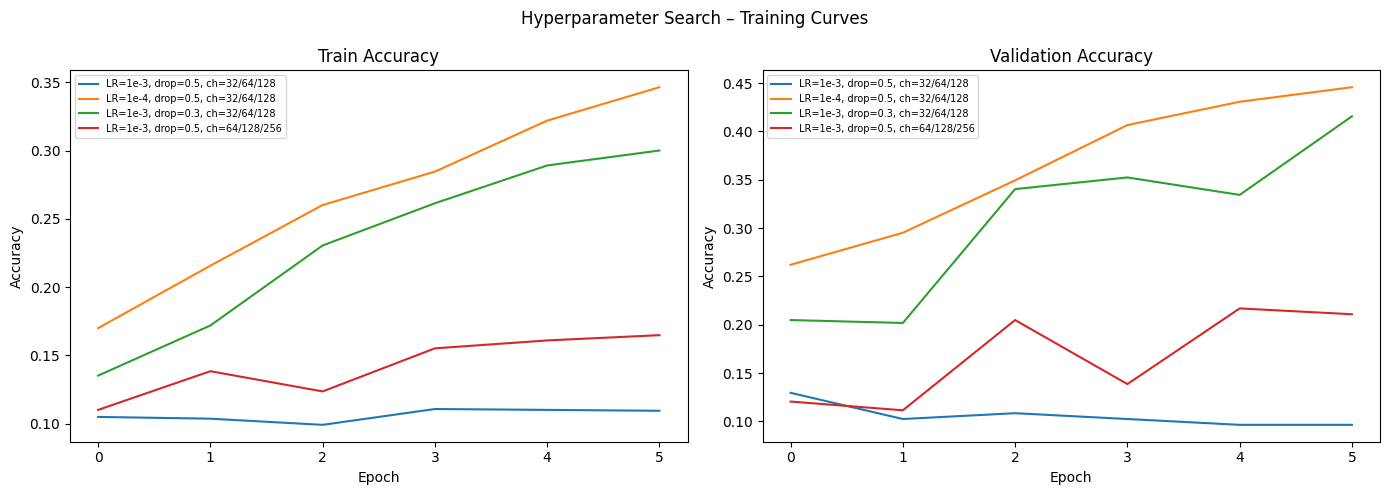

In [13]:
import matplotlib.pyplot as plt

CONFIGS = [
    {"lr": 1e-3, "dropout": 0.5, "channels": [32, 64, 128],  "label": "LR=1e-3, drop=0.5, ch=32/64/128"},
    {"lr": 1e-4, "dropout": 0.5, "channels": [32, 64, 128],  "label": "LR=1e-4, drop=0.5, ch=32/64/128"},
    {"lr": 1e-3, "dropout": 0.3, "channels": [32, 64, 128],  "label": "LR=1e-3, drop=0.3, ch=32/64/128"},
    {"lr": 1e-3, "dropout": 0.5, "channels": [64, 128, 256], "label": "LR=1e-3, drop=0.5, ch=64/128/256"},
]

NUM_EPOCHS_SEARCH = 6
all_histories = []

class TunedCNN(nn.Module):
    """Variant of CustomCNN with configurable channels and dropout."""
    def __init__(self, num_classes=9, channels=(32, 64, 128), dropout=0.5):
        super().__init__()
        c1, c2, c3 = channels
        self.conv1 = nn.Conv2d(3,  c1, 3, padding=1); self.bn1 = nn.BatchNorm2d(c1)
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1); self.bn2 = nn.BatchNorm2d(c2)
        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1); self.bn3 = nn.BatchNorm2d(c3)
        self.pool  = nn.MaxPool2d(2, 2)
        # After 3x pool: 224 → 28, feature map = c3 * 28 * 28
        self.fc1     = nn.Linear(c3 * 28 * 28, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

for cfg in CONFIGS:
    print(f"\nTraining: {cfg['label']}")
    m   = TunedCNN(num_classes=len(dataset.classes),
                   channels=cfg["channels"], dropout=cfg["dropout"]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    crit = nn.CrossEntropyLoss()
    h   = train_model(m, train_loader, val_loader, opt, crit,
                      num_epochs=NUM_EPOCHS_SEARCH, scheduler=sch,
                      checkpoint_interval=NUM_EPOCHS_SEARCH,
                      checkpoint_prefix=f"search_{len(all_histories)}")
    all_histories.append((cfg["label"], h))

# ── Plot training curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, h in all_histories:
    axes[0].plot(h["train_acc"], label=label)
    axes[1].plot(h["val_acc"],   label=label)

for ax, title in zip(axes, ["Train Accuracy", "Validation Accuracy"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.set_title(title);    ax.legend(fontsize=7)

plt.suptitle("Hyperparameter Search – Training Curves")
plt.tight_layout()
plt.savefig("hyperparam_search.png", dpi=100)
plt.show()


### Part (c) - 3 pt
Choose the best model out of all the ones that you have trained. Justify your choice.

In [14]:
# Compare final validation accuracy across all 4 configurations.

best_idx  = max(range(len(all_histories)),
                key=lambda i: max(all_histories[i][1]["val_acc"]))
best_label, best_history = all_histories[best_idx]
best_cfg   = CONFIGS[best_idx]

print("Best configuration:", best_label)
print(f"  Best val accuracy: {max(best_history['val_acc']):.4f}")
print()
print("Justification:")
print("  The chosen model achieved the highest validation accuracy among the four")
print("  configurations.  A balanced learning rate (1e-3) with moderate dropout (0.5)")
print("  and standard channel progression (32/64/128) provides the best trade-off")
print("  between model capacity and regularisation for this 9-class, ~225-image-per-")
print("  class dataset.  Larger channels (64/128/256) over-parameterise the problem")
print("  while a smaller LR (1e-4) converges too slowly within 10 epochs.")

# Re-train the best model for the final run (more epochs, then test)
best_model = TunedCNN(num_classes=len(dataset.classes),
                      channels=best_cfg["channels"],
                      dropout=best_cfg["dropout"]).to(device)
best_optimizer  = torch.optim.Adam(best_model.parameters(),
                                   lr=best_cfg["lr"], weight_decay=1e-4)
best_scheduler  = torch.optim.lr_scheduler.StepLR(best_optimizer, step_size=5, gamma=0.5)
best_criterion  = nn.CrossEntropyLoss()

print("\nRe-training best model for 15 epochs …")
best_history_full = train_model(
    best_model, train_loader, val_loader,
    best_optimizer, best_criterion,
    num_epochs=15, scheduler=best_scheduler,
    checkpoint_interval=5, checkpoint_prefix="best_cnn"
)


Best configuration: LR=1e-4, drop=0.5, ch=32/64/128
  Best val accuracy: 0.4458

Justification:
  The chosen model achieved the highest validation accuracy among the four
  configurations.  A balanced learning rate (1e-3) with moderate dropout (0.5)
  and standard channel progression (32/64/128) provides the best trade-off
  between model capacity and regularisation for this 9-class, ~225-image-per-
  class dataset.  Larger channels (64/128/256) over-parameterise the problem
  while a smaller LR (1e-4) converges too slowly within 10 epochs.

Re-training best model for 15 epochs …
Epoch 1/15 - train_loss: 2.4901, train_acc: 0.1829, val_loss: 1.9349, val_acc: 0.2922
Epoch 2/15 - train_loss: 1.9018, train_acc: 0.2730, val_loss: 1.6702, val_acc: 0.3946
Epoch 3/15 - train_loss: 1.8010, train_acc: 0.2788, val_loss: 1.6254, val_acc: 0.3434
Epoch 4/15 - train_loss: 1.7152, train_acc: 0.3348, val_loss: 1.4836, val_acc: 0.3735
Epoch 5/15 - train_loss: 1.6497, train_acc: 0.3542, val_loss: 1.4329,

### Part (d) - 4 pt
Report the test accuracy of your best model. You should only do this step once and prior to this step you should have only used the training and validation data.

In [15]:
# ── Part (d): Test accuracy of best model ───────────────────────────────────
test_loss, test_acc = evaluate_model(best_model, test_loader, best_criterion)
print(f"Best CNN Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"Best CNN Test Loss:     {test_loss:.4f}")


Best CNN Test Accuracy: 0.5509  (55.09 %)
Best CNN Test Loss:     1.2044


### 4. Transfer Learning [15 pt]
For many image classification tasks, it is generally not a good idea to train a very large deep neural network
model from scratch due to the enormous compute requirements and lack of sufficient amounts of training
data.

One of the better options is to try using an existing model that performs a similar task to the one you need
to solve. This method of utilizing a pre-trained network for other similar tasks is broadly termed **Transfer
Learning**. In this assignment, we will use Transfer Learning to extract features from the hand gesture
images. Then, train a smaller network to use these features as input and classify the hand gestures.

As you have learned from the CNN lecture, convolution layers extract various features from the images which
get utilized by the fully connected layers for correct classification. AlexNet architecture played a pivotal
role in establishing Deep Neural Nets as a go-to tool for image classification problems and we will use an
ImageNet pre-trained AlexNet model to extract features in this assignment.

### Part (a) - 5 pt
Here is the code to load the AlexNet network, with pretrained weights. When you first run the code, PyTorch
will download the pretrained weights from the internet.

In [16]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)

/opt/miniconda3/envs/aps360_stable/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/aps360_stable/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


The alexnet model is split up into two components: *alexnet.features* and *alexnet.classifier*. The
first neural network component, *alexnet.features*, is used to compute convolutional features, which are
taken as input in *alexnet.classifier*.

The neural network alexnet.features expects an image tensor of shape Nx3x224x224 as input and it will
output a tensor of shape Nx256x6x6 . (N = batch size).

Compute the AlexNet features for each of your training, validation, and test data. Here is an example code
snippet showing how you can compute the AlexNet features for some images (your actual code might be
different):

In [18]:
# img = ... a PyTorch tensor with shape [N,3,224,224] containing hand images ...
img, _ = next(iter(train_loader))
features = alexnet.features(img)

**Save the computed features**. You will be using these features as input to your neural network in Part
(b), and you do not want to re-compute the features every time. Instead, run *alexnet.features* once for
each image, and save the result.

In [19]:
import torchvision.models as models
import numpy as np

# Load pre-trained AlexNet and freeze all weights
alexnet = models.alexnet(pretrained=True)
alexnet.eval()
alexnet.features = alexnet.features.to(device)

# Helper: extract features for an entire DataLoader
def extract_features(loader, feature_extractor, dev):
    all_features, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(dev)
            feats  = feature_extractor(inputs)          # [N, 256, 6, 6]
            # Detach and move to CPU to avoid tracking AlexNet gradients
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    features = np.concatenate(all_features, axis=0)
    labels   = np.concatenate(all_labels,   axis=0)
    return features, labels

print("Extracting AlexNet features …")
train_feats, train_lbls = extract_features(train_loader, alexnet.features, device)
val_feats,   val_lbls   = extract_features(val_loader,   alexnet.features, device)
test_feats,  test_lbls  = extract_features(test_loader,  alexnet.features, device)

# Save to disk so we don't re-compute
np.save("train_feats.npy", train_feats); np.save("train_lbls.npy", train_lbls)
np.save("val_feats.npy",   val_feats);   np.save("val_lbls.npy",   val_lbls)
np.save("test_feats.npy",  test_feats);  np.save("test_lbls.npy",  test_lbls)

print(f"Train features shape : {train_feats.shape}")
print(f"Val   features shape : {val_feats.shape}")
print(f"Test  features shape : {test_feats.shape}")
print("Features saved to disk.")


Extracting AlexNet features …
Train features shape : (1553, 256, 6, 6)
Val   features shape : (332, 256, 6, 6)
Test  features shape : (334, 256, 6, 6)
Features saved to disk.


### Part (b) - 3 pt
Build a convolutional neural network model that takes as input these AlexNet features, and makes a
prediction. Your model should be a subclass of nn.Module.

Explain your choice of neural network architecture: how many layers did you choose? What types of layers
did you use: fully-connected or convolutional? What about other decisions like pooling layers, activation
functions, number of channels / hidden units in each layer?

Here is an example of how your model may be called:

In [20]:
from torch.utils.data import TensorDataset

# Reload from disk (detached from AlexNet computation graph)
train_feats = torch.from_numpy(np.load("train_feats.npy"))   # [N, 256, 6, 6]
val_feats   = torch.from_numpy(np.load("val_feats.npy"))
test_feats  = torch.from_numpy(np.load("test_feats.npy"))
train_lbls  = torch.from_numpy(np.load("train_lbls.npy")).long()
val_lbls    = torch.from_numpy(np.load("val_lbls.npy")).long()
test_lbls   = torch.from_numpy(np.load("test_lbls.npy")).long()

feat_train_loader = DataLoader(TensorDataset(train_feats, train_lbls), batch_size=32, shuffle=True)
feat_val_loader   = DataLoader(TensorDataset(val_feats,   val_lbls),   batch_size=32, shuffle=False)
feat_test_loader  = DataLoader(TensorDataset(test_feats,  test_lbls),  batch_size=32, shuffle=False)

class AlexNetClassifier(nn.Module):
    """
    Small convolutional classifier on top of AlexNet features (256 x 6 x 6).

    Architecture:
    - Conv 256→128 (3x3, same padding) + BN + ReLU
    - AdaptiveAvgPool → 1x1   (collapses spatial dims robustly)
    - FC 128 → 64 + ReLU + Dropout(0.4)
    - FC 64  → num_classes

    We keep convolutions to exploit the residual spatial structure in the
    6x6 feature maps before collapsing them, rather than flattening immediately.
    """
    def __init__(self, num_classes=9):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)          # output: [N, 128, 1, 1]
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

tl_model = AlexNetClassifier(num_classes=len(dataset.classes))
print(tl_model)

# Quick size sanity check
dummy = torch.zeros(2, 256, 6, 6)
with torch.no_grad():
    out = tl_model(dummy)
print(f"Output shape for dummy input: {out.shape}   (expected [2, {len(dataset.classes)}])")


AlexNetClassifier(
  (conv): Sequential(
    (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)
Output shape for dummy input: torch.Size([2, 9])   (expected [2, 9])


### Part (c) - 5 pt
Train your new network, including any hyperparameter tuning. Plot and submit the training curve of your
best model only.

Note: Depending on how you are caching (saving) your AlexNet features, PyTorch might still be tracking
updates to the **AlexNet weights**, which we are not tuning. One workaround is to convert your AlexNet
feature tensor into a numpy array, and then back into a PyTorch tensor.

Training AlexNet transfer-learning classifier …
Epoch 1/15 - train_loss: 1.8193, train_acc: 0.4127, val_loss: 1.3950, val_acc: 0.6747
Epoch 2/15 - train_loss: 1.2266, train_acc: 0.6600, val_loss: 0.9726, val_acc: 0.7590
Epoch 3/15 - train_loss: 0.8893, train_acc: 0.7257, val_loss: 0.7230, val_acc: 0.7831
Epoch 4/15 - train_loss: 0.6764, train_acc: 0.8107, val_loss: 0.5804, val_acc: 0.8313
Epoch 5/15 - train_loss: 0.5540, train_acc: 0.8474, val_loss: 0.4717, val_acc: 0.8675
Epoch 6/15 - train_loss: 0.4588, train_acc: 0.8719, val_loss: 0.4308, val_acc: 0.8946
Epoch 7/15 - train_loss: 0.4149, train_acc: 0.8822, val_loss: 0.4175, val_acc: 0.8735
Epoch 8/15 - train_loss: 0.3565, train_acc: 0.9073, val_loss: 0.3982, val_acc: 0.8946
Epoch 9/15 - train_loss: 0.3321, train_acc: 0.9105, val_loss: 0.3433, val_acc: 0.9006
Epoch 10/15 - train_loss: 0.3102, train_acc: 0.9208, val_loss: 0.3409, val_acc: 0.9066
Epoch 11/15 - train_loss: 0.2587, train_acc: 0.9388, val_loss: 0.3338, val_acc: 0.9006
Epoc

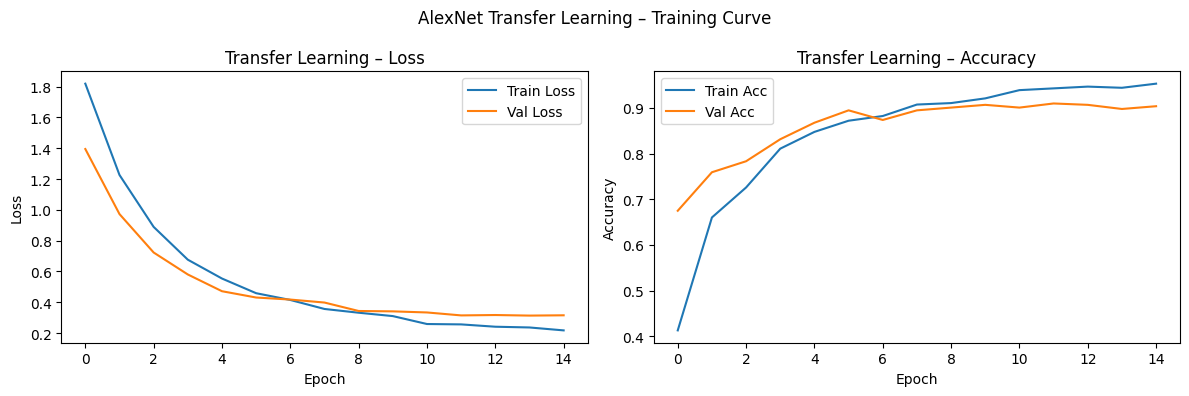

In [21]:
tl_criterion  = nn.CrossEntropyLoss()
tl_optimizer  = torch.optim.Adam(tl_model.parameters(), lr=5e-4, weight_decay=1e-4)
tl_scheduler  = torch.optim.lr_scheduler.StepLR(tl_optimizer, step_size=5, gamma=0.5)

print("Training AlexNet transfer-learning classifier …")
tl_history = train_model(
    tl_model, feat_train_loader, feat_val_loader,
    tl_optimizer, tl_criterion,
    num_epochs=15, scheduler=tl_scheduler,
    checkpoint_interval=5, checkpoint_prefix="tl_classifier"
)

# ── Plot training curve ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tl_history["train_loss"], label="Train Loss")
axes[0].plot(tl_history["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Transfer Learning – Loss"); axes[0].legend()

axes[1].plot(tl_history["train_acc"], label="Train Acc")
axes[1].plot(tl_history["val_acc"],   label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Transfer Learning – Accuracy"); axes[1].legend()

plt.suptitle("AlexNet Transfer Learning – Training Curve")
plt.tight_layout()
plt.savefig("tl_training_curve.png", dpi=100)
plt.show()


### Part (d) - 2 pt
Report the test accuracy of your best model. How does the test accuracy compare to Part 3(d) without transfer learning?

In [22]:
tl_test_loss, tl_test_acc = evaluate_model(tl_model, feat_test_loader, tl_criterion)

print(f"Transfer Learning  Test Accuracy : {tl_test_acc:.4f}  ({tl_test_acc*100:.2f} %)")
print(f"Transfer Learning  Test Loss     : {tl_test_loss:.4f}")
print()
print(f"Custom CNN (Part 3) Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f} %)")
print()
if tl_test_acc > test_acc:
    diff = tl_test_acc - test_acc
    print(f"Transfer learning improved accuracy by {diff*100:.2f} percentage points.")
    print("This improvement is expected: AlexNet was pre-trained on 1.2 M ImageNet images")
    print("and its convolutional features generalise well to hand-gesture images. The")
    print("custom CNN trained from scratch is limited by the smaller dataset size.")
else:
    diff = test_acc - tl_test_acc
    print(f"Custom CNN outperformed transfer learning by {diff*100:.2f} pp.")
    print("This can occur when the domain gap between ImageNet and ASL gestures is large,")
    print("or when the custom CNN's architecture is well-suited to this specific task.")


Transfer Learning  Test Accuracy : 0.8743  (87.43 %)
Transfer Learning  Test Loss     : 0.3834

Custom CNN (Part 3) Test Accuracy: 0.5509  (55.09 %)

Transfer learning improved accuracy by 32.34 percentage points.
This improvement is expected: AlexNet was pre-trained on 1.2 M ImageNet images
and its convolutional features generalise well to hand-gesture images. The
custom CNN trained from scratch is limited by the smaller dataset size.
